In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import re
import seaborn as sns
from math import radians, sin, cos, asin, sqrt
import imageio
import os
from IPython.display import Image, display
import time
from scipy.stats import gaussian_kde
from statistics import mean
import statistics
import random

In [2]:
plotdir = 'plots/'

In [3]:
Ms = 10 #number of importance samples
CHR = 2
tCutoff = 'None'
samples = range(1746*2)
samples_contemporary = range(556)
ancestor_loci = [int(i * 51845 / 999) for i in range(1000)]

In [4]:
#Loading all the loci to get the mean later
pattern = 'data/SGDP_aDNA_new_filtered_chr2_*locus_10M_NoneT_Alls_Allt.blup_weightless_locs'

fns = sorted(glob.iglob(pattern))
starts = [int(re.search(r'chr2_(\d+)locus', fn).group(1)) for fn in fns]
locus_order = np.argsort(starts)
fnss_0 = [fns[i] for i in locus_order]


# anc_locs_0 = []
# for i,fns in enumerate(fnss_0):
#     anc_loc = np.loadtxt(fns, delimiter=',')
#     anc_locs_0.append(anc_loc)

# anc_locs_0 = np.array(anc_locs_0)
# anc_locs_0 = np.swapaxes(anc_locs_0,0,1)
# L, n, T, d = anc_locs_0.shape
# L, n, T, d 

anc_locs_0 = []
for i, fpath in enumerate(fnss_0):
    df = pd.read_csv(fpath, header=None, names=["sample", "time", "lat", "lon", "var"])
    samples = sorted(df["sample"].unique())
    timepoints = sorted(df["time"].unique())

    n = len(samples)
    T = len(timepoints)

    if n * T != len(df):
        print(f"Skipping {fpath}: expected {n*T} rows but got {len(df)}")
        continue
    sample_map = {v: i for i, v in enumerate(samples)}
    time_map = {v: i for i, v in enumerate(timepoints)}

    # Map samples and times to indices
    s_idx = df["sample"].map(sample_map).values
    t_idx = df["time"].map(time_map).values

    # Pre-allocate array
    arr = np.full((n, T, 2), np.nan)

    # Fill lat/lon efficiently using broadcasting
    arr[s_idx, t_idx, 0] = df["lon"].values
    arr[s_idx, t_idx, 1] = df["lat"].values

    anc_locs_0.append(arr)

anc_locs_0 = np.array(anc_locs_0)  # shape: (L, n, T, 2)
print("Final shape:", anc_locs_0.shape)

anc_locs = anc_locs_0

L, n, T, d = anc_locs.shape
L, n, T, d

Final shape: (999, 3492, 10, 2)


(999, 3492, 10, 2)

In [5]:
ancestor_times = np.logspace(np.log10(4),np.log10(40000),10)
ancestor_times

array([4.00000000e+00, 1.11302376e+01, 3.09705473e+01, 8.61773876e+01,
       2.39793700e+02, 6.67240215e+02, 1.85663553e+03, 5.16619866e+03,
       1.43752547e+04, 4.00000000e+04])

In [6]:
sample_locs = np.loadtxt("data/SGDP_aDNA_new_filtered.locations")
sample_locs= sample_locs[:, [1, 0]] #Flip it so it transforms from lat-lon to lon-lat (same format as anc_locs)
print(sample_locs.shape)

(3492, 2)


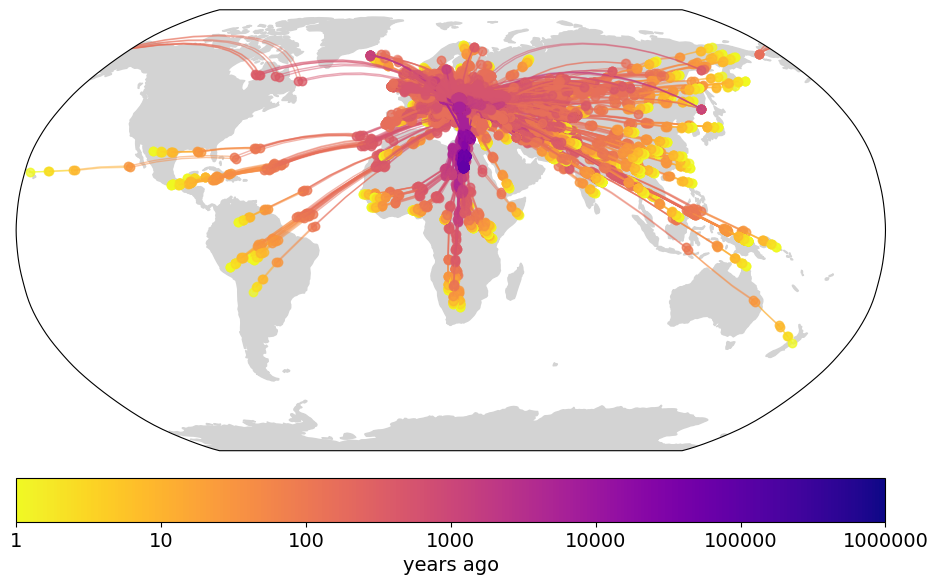

In [7]:
#plotting
fig = plt.figure(figsize=(10, 6), dpi=100, edgecolor='k')
projection = ccrs.Robinson(central_longitude=20)
data_crs = ccrs.PlateCarree() #data supplied in lat/long
geodetic = ccrs.Geodetic() #for great circles
ax = plt.axes(projection=projection)
ax.set_global()
ax.add_feature(cfeature.LAND, color='lightgray')
cmap = plt.get_cmap("plasma_r")

for sample in samples: #samples: #for each sample
    #print(df_poplabels["pop"][int(sample/2)])
    # if (sample > 277*2 ):
    #     break #Skip by 20 to thin num of samples
    #print(sample, "Population", df_poplabels["pop"][sample], " Group ", df_poplabels["group"][sample])
    # get mean ancestor location at all times
    mean_locs = [sample_locs[sample]]
    # time_loc = locations[sample] #start with sample location
    for time_ix in range(T): #exclude late times as numerical issues
        locs = anc_locs[:,sample,time_ix] #locations of all ancestors
        if np.isnan(locs).all(): #No loci has a valid location yet
            mean_loc = [np.nan, np.nan]  # placeholder, will be skipped in plot
        else:
            mean_loc = np.nanmean(locs, axis=0) #mean ancestor location ignorning nans   
        mean_locs.append(mean_loc)
    mean_locs = np.array(mean_locs)


    # plot trajectory of mean ancestor colored by time
    for i in range(len(mean_locs)-1):
        color = cmap(i / len(mean_locs))
        x0,y0 = mean_locs[i, 0], mean_locs[i, 1]
        x1,y1 = mean_locs[i+1, 0], mean_locs[i+1, 1]

        if np.any(np.isnan([x0, y0, x1, y1])):
            #print(i)
            continue
        ax.plot([x0,x1], [y0,y1], color=color, lw=1, alpha=0.5, transform=geodetic, marker='o') #great circles
        # ax.plot([x0,x1], [y0,y1], color=color, lw=1, alpha=0.5, transform=data_crs) #straight lines

cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap=cmap), ax=ax, orientation='horizontal', pad=0.05, shrink=0.9)
# cbar.set_ticks([i/4 for i in range(5)])
# cbar.set_ticklabels(np.round(np.logspace(1,np.log10(ancestor_times[time_ix]),5)*25).astype(int).tolist())
ts = [10**i for i in range(7)]
cbar.set_ticks(np.log10(ts)/np.log10(ancestor_times[time_ix]*25)) #gen time = 25 years
cbar.set_ticklabels(ts)
cbar.set_label(('years ago'), fontsize=14)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig(plotdir + 'ancient_inference_only_contemporary_samples.png')
plt.show()

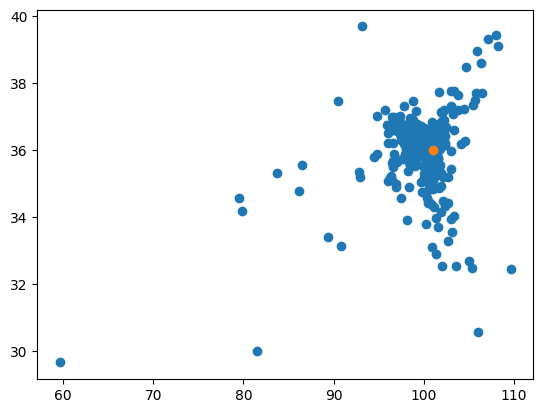

In [8]:
sample_num = 500
x = anc_locs[:, sample_num, 0, 0]
y = anc_locs[:, sample_num, 0, 1]
mask = ~np.isnan(x) & ~np.isnan(y)
#print(mask)
plt.scatter(x[mask],y[mask])
plt.scatter(sample_locs[sample_num,0], sample_locs[sample_num,1])
# plt.ylim(-15, 10)
# plt.xlim(20,160)

# for i in range(len(y)):
#     if (x[i] < 40):
#         print(fns[i])



In [9]:
from utils import chop_shared_times
stss = np.loadtxt('data/SGDP_aDNA_new_filtered_chr2_39389locus_10M.stss', delimiter=',') #load in the shared time matrices
print(stss.shape) # shape = MX(NXN)


(10, 6098778)


In [10]:
sts = stss[0] #Just get the shared time matrix for the first importance sample
# convert to matrix form
k = int((np.sqrt(1+8*len(sts))-1)/2) #get size of matrix (from sum_i=0^k i = k(k+1)/2), allows for non-contemporary samples
sts_mat = np.zeros((k,k)) #initialize matrix
sts_mat[np.triu_indices(k, k=0)] = sts #convert to numpy matrix
sts_mat = sts_mat + sts_mat.T - np.diag(np.diag(sts_mat)) #fill in all entries
sts = sts_mat

# sample times
x = np.diag(sts)
x = np.max(x) - x
sample_times = np.sort(x)
print(sample_times) #Each sample time has 3492 columns

[0.00000000e+00 2.00000068e-06 1.20000041e-05 ... 1.33821012e+03
 1.60786011e+03 1.60786300e+03]


In [11]:
#print(sample_times[0:500])

10 3492


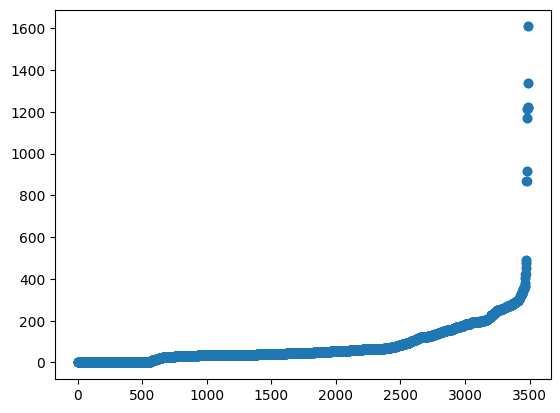

In [12]:
print(len(ancestor_times), len(sample_times))
plt.scatter(range(len(sample_times)), sample_times) #When were samples taken
plt.show()

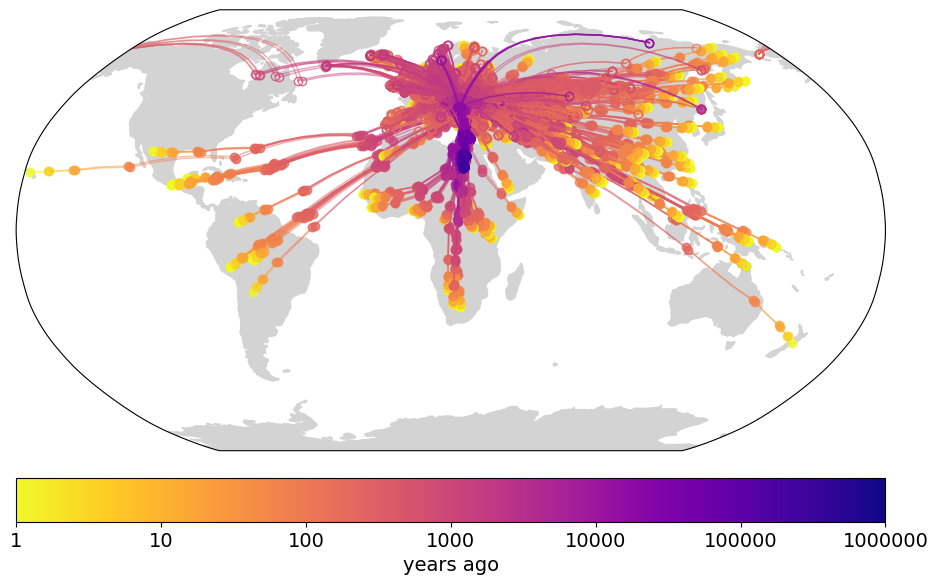

In [13]:
# Using continuous logarithmic color map 
from matplotlib.colors import LogNorm
fig = plt.figure(figsize=(10, 6), dpi=100, edgecolor='k')
projection = ccrs.Robinson(central_longitude=20)
data_crs = ccrs.PlateCarree() #data supplied in lat/long
geodetic = ccrs.Geodetic() #for great circles
ax = plt.axes(projection=projection)
ax.set_global()
ax.add_feature(cfeature.LAND, color='lightgray')
cmap = plt.get_cmap("plasma_r")
norm = LogNorm(vmin=1, vmax=40005)


for sample in samples: #samples: #for each sample
    #if (sample != 3000):
        #continue
    # get mean ancestor location at all times
    time_vals = []  # store when we start collecting samples

    sample_added = False
    mean_locs = []
    sample_time = sample_times[sample]
    is_ancient = []
    

    for time_ix in range(T):
        if ancestor_times[time_ix] < sample_time:
            #assert np.isnan(anc_locs[:, sample, time_ix]).all() #ensure that we only have nans
            try:
                assert np.isnan(anc_locs[:, sample, time_ix]).all()
            except AssertionError:
                print(f"Assertion failed at sample={sample}, time_ix={time_ix}")
                print(f"anc_locs[:, sample, time_ix] = {anc_locs[:, sample, time_ix]}")
                raise
            #time_vals.append(-1)
            #mean_locs.append(-1)
            is_ancient.append(True)
            continue

        if not sample_added:
            mean_locs.append(sample_locs[sample])
            time_vals.append(sample_time)
            sample_added = True

        locs = anc_locs[:, sample, time_ix]
        assert not np.isnan(locs).any() #check there are NO nans
        mean_loc = np.mean(locs, axis=0)
        mean_locs.append(mean_loc)
        time_vals.append(ancestor_times[time_ix])
        is_ancient.append(False)

    mean_locs = np.array(mean_locs)
    time_vals = np.array(time_vals)

    assert (len(mean_locs) == len(time_vals))
    for i in range(len(mean_locs) - 1):
        # t_norm = (time_vals[i+1] - min_time) / (max_time - min_time)
        # color = cmap(t_norm)
        if time_vals[i] == 0:
            color = 'black'
        else:
            color = cmap(norm(time_vals[i]))

        x0, y0 = mean_locs[i, 0], mean_locs[i, 1]
        x1, y1 = mean_locs[i+1, 0], mean_locs[i+1, 1]

        if np.any(np.isnan([x0, y0, x1, y1])):
            continue

        if (is_ancient[i]):
            ax.plot([x0, x1], [y0, y1], color=color, lw=1, alpha=0.5,
                    transform=geodetic, marker='o', markerfacecolor='none')
        else:
            ax.plot([x0, x1], [y0, y1], color=color, lw=1, alpha=0.5,
                    transform=geodetic, marker='o')

cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap=cmap), ax=ax, orientation='horizontal', pad=0.05, shrink=0.9)
# cbar.set_ticks([i/4 for i in range(5)])
# cbar.set_ticklabels(np.round(np.logspace(1,np.log10(ancestor_times[time_ix]),5)*25).astype(int).tolist())
ts = [10**i for i in range(7)]
cbar.set_ticks(np.log10(ts)/np.log10(ancestor_times[time_ix]*25)) #gen time = 25 years
cbar.set_ticklabels(ts)
cbar.set_label(('years ago'), fontsize=14)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig(plotdir + 'continous_log_time_scale.png')
plt.show()
#print(f'Number of ancient samples: {count_ancients}')

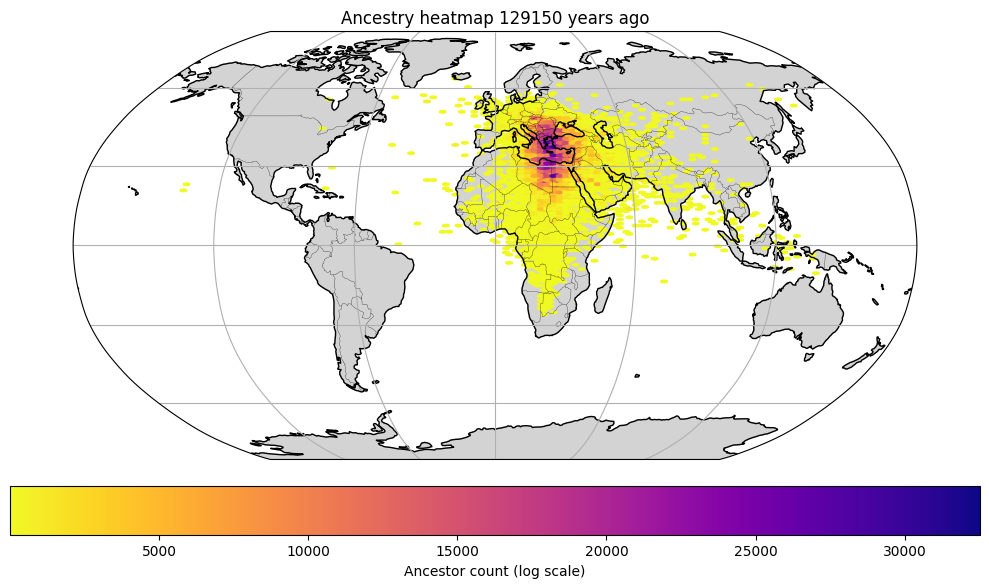

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Choose a time point
time_ix = 7

# Collect lat/lon from all loci and samples at that time
locs_at_time = anc_locs[:, :, time_ix, :]  # shape: (L, N, 2)
latlon = locs_at_time.reshape(-1, 2)  # shape: (L*N, 2)


# Set up map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.BORDERS, linewidth=0.2)
ax.gridlines(draw_labels=False)

# Plot heatmap
hb = ax.hexbin(
    latlon[:, 0],  # longitude
    latlon[:, 1],  # latitude
    gridsize=100,
    transform=ccrs.PlateCarree(),
    cmap='plasma_r',
    mincnt=1
)

cbar = plt.colorbar(hb, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Ancestor count (log scale)')

plt.title(f'Ancestry heatmap {int(ancestor_times[time_ix]) * 25} years ago')
plt.tight_layout()
plt.show()


In [15]:
#Plot by region
region_mapping = {
    # Broad cultural-geopolitical regions

    # Oceania & Pacific
    "Oceania": "Oceania",

    # Sub-Saharan Africa
    "Africa": "Sub-Saharan Africa",

    # East Asia
    "EastAsia": "East Asia",
    "China": "East Asia",
    "Japan": "East Asia",
    "Korea": "East Asia",

    # South Asia
    "SouthAsia": "South Asia",
    "India": "South Asia",
    "Pakistan": "South Asia",
    "Sri Lanka": "South Asia",
    "Bangladesh": "South Asia",

    # Central Asia
    "CentralAsiaSiberia": "Central Asia",
    "Kazakhstan": "Central Asia",
    "Kyrgyzstan": "Central Asia",
    "Turkmenistan": "Central Asia",
    "Uzbekistan": "Central Asia",
    "Mongolia": "Central Asia",

    # Middle East / Southwest Asia
    "Iran": "Middle East",
    "Turkey": "Middle East",
    "Lebanon": "Middle East",
    "Syria": "Middle East",
    "Armenia": "Caucasus",
    "Georgia": "Caucasus",

    # Eastern Europe
    "Russia": "Eastern Europe",
    "Ukraine": "Eastern Europe",
    "Poland": "Eastern Europe",
    "Estonia": "Eastern Europe",
    "Latvia": "Eastern Europe",
    "Lithuania": "Eastern Europe",
    "Romania": "Eastern Europe",
    "Hungary": "Eastern Europe",
    "Slovakia": "Eastern Europe",
    "Czech_Republic": "Eastern Europe",
    "Serbia": "Eastern Europe",
    "Montenegro": "Eastern Europe",
    "Croatia": "Eastern Europe",
    "Slovenia": "Eastern Europe",
    "Bulgaria": "Eastern Europe",

    # Western Europe
    "France": "Western Europe",
    "Germany": "Western Europe",
    "Switzerland": "Western Europe",
    "Austria": "Western Europe",
    "Belgium": "Western Europe",
    "Netherlands": "Western Europe",
    "Luxembourg": "Western Europe",

    # Southern Europe
    "Italy": "Southern Europe",
    "Spain": "Southern Europe",
    "Portugal": "Southern Europe",
    "Greece": "Southern Europe",

    # Northern Europe
    "Denmark": "Northern Europe",
    "Sweden": "Northern Europe",
    "Norway": "Northern Europe",
    "Finland": "Northern Europe",
    "Iceland": "Northern Europe",
    "Faroes": "Northern Europe",
    "Greenland": "Northern Europe",

    # British Isles
    "UK": "British Isles",
    "England": "British Isles",
    "Scotland": "British Isles",
    "Ireland": "British Isles",
    "IsleOfMan": "British Isles",
    "United_Kingdom": "British Isles",

    # Americas
    "America": "Americas",
    "United_States": "Americas",
    "Canada": "Americas",
    "Mexico": "Americas",
    "Brazil": "Americas",
    "Chile": "Americas",
    "Argentina": "Americas",
    "Peru": "Americas",
    "Colombia": "Americas",

    # North Africa (distinct from Sub-Saharan)
    "Algeria": "North Africa",
    "Tunisia": "North Africa",

    # Unclassified
    "WestEurasia": "West Eurasia",  # Often overlaps with Europe & Middle East
}

poplabels = 'data/SGDP_aDNA_new_filtered_chr2.poplabels'
ids = []
groups = []
i = 0
with open(poplabels, "r") as f:
    next(f) #Skip header
    for line in f:
        # if (i == 278):
        #     break #Contemporary only
        l = line.strip().split(' ') #Split words by spaces
        ids.append(l[0]) #ID is the first word, add it
        groups.append(l[2])
        i += 1
    groups = [item for item in groups for _ in range(2)]
        
ids = [s[:-3] if s.endswith('.DG') else s for s in ids] #Remove the trailing .DG (signifying high coverage contemporary samples)

group_names = []
for group in groups:
    group_names.append(region_mapping[group])


group_names, group_ixs = np.unique(group_names, return_inverse=True)
print(group_ixs)
# print(group_names)
# give each group a color
group_colors = [
    'yellow', 'red', 'pink', 'green', 'brown',
    'purple', 'lightblue', 'orange', 'teal', 'gray',
    'navy', 'gold', 'cyan', 'magenta', 'olive'
]

[9 9 9 ... 5 5 5]


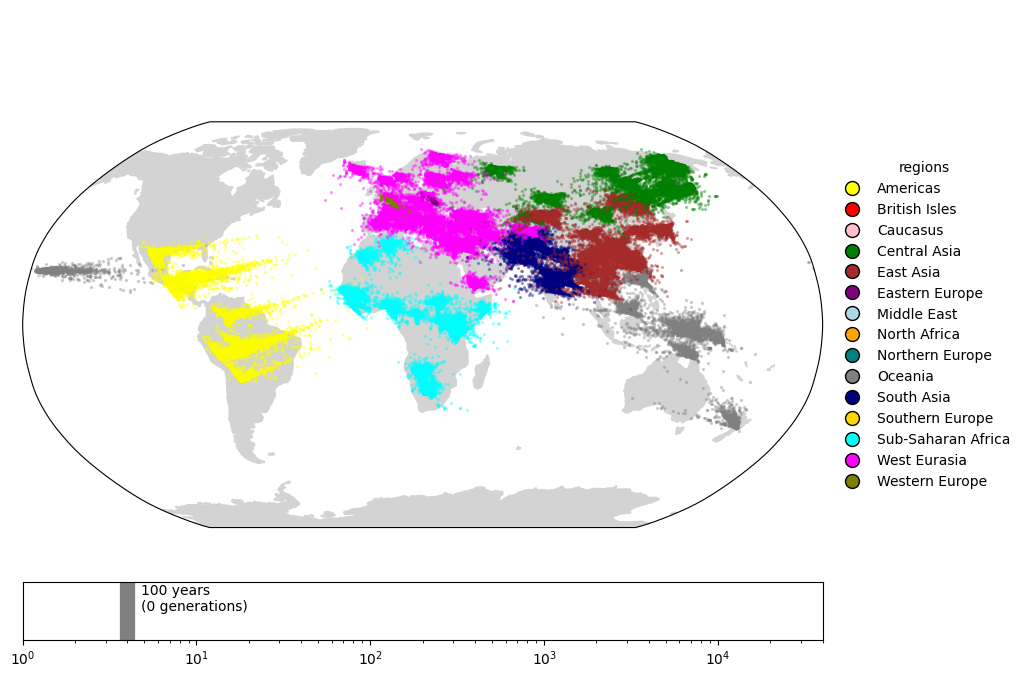

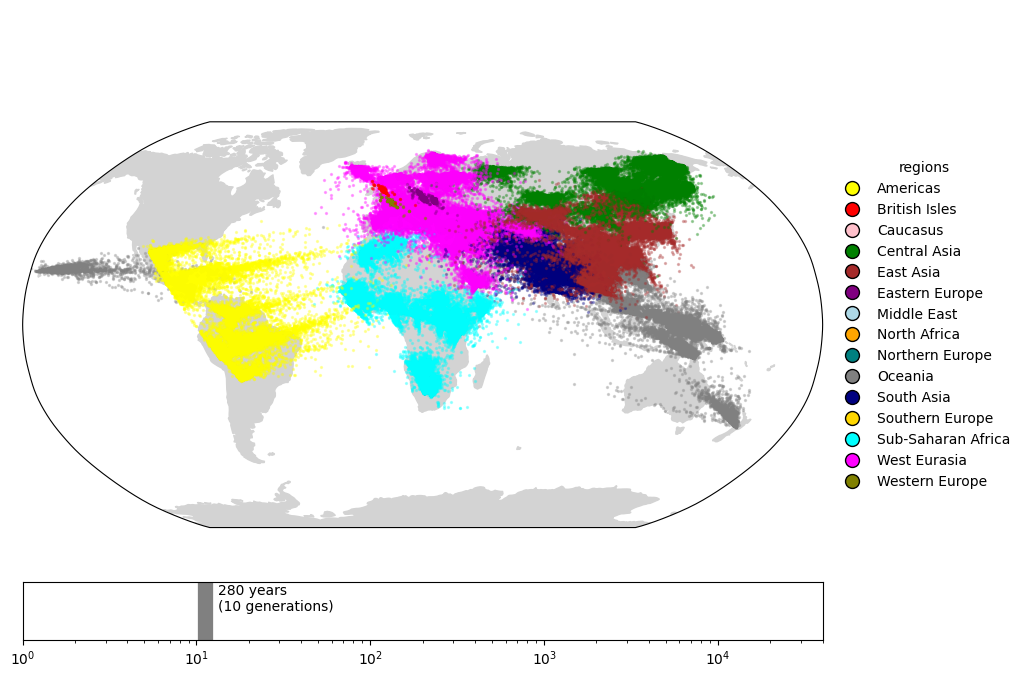

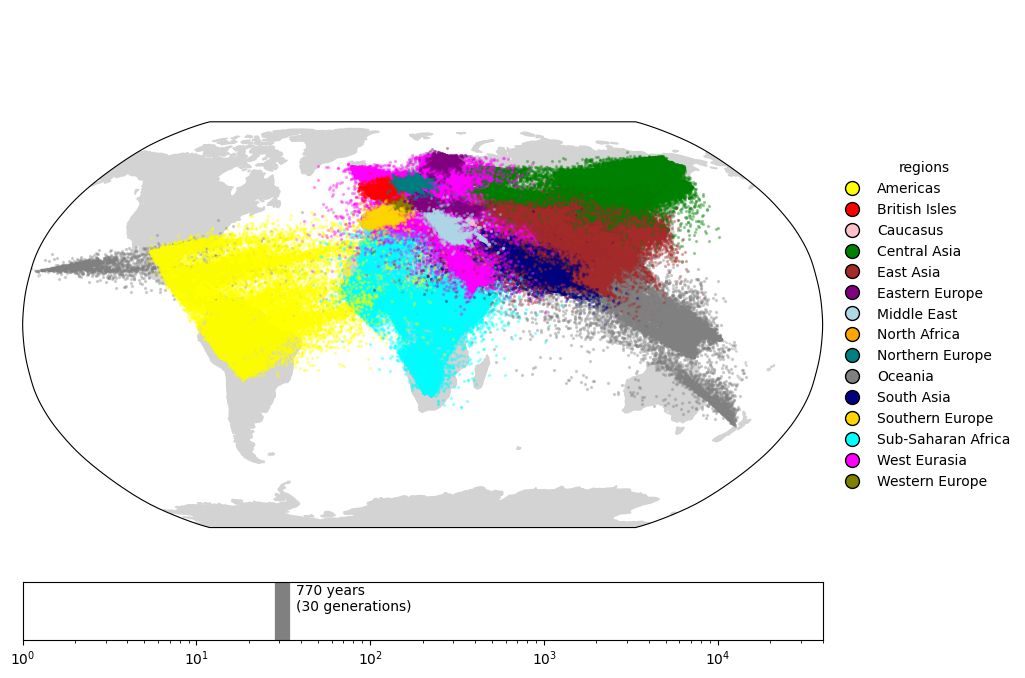

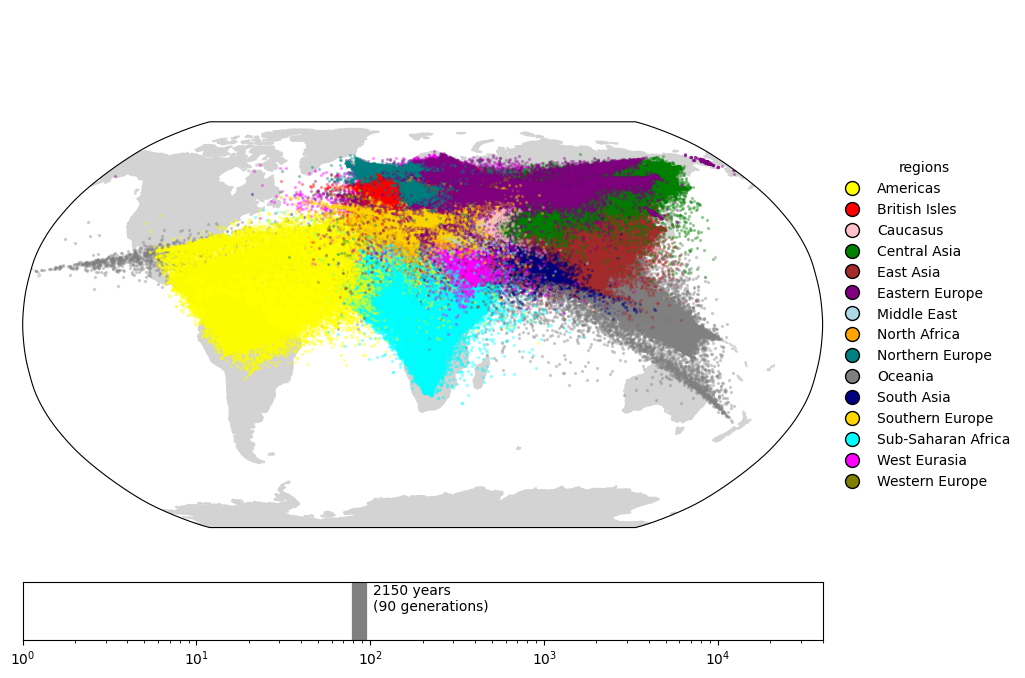

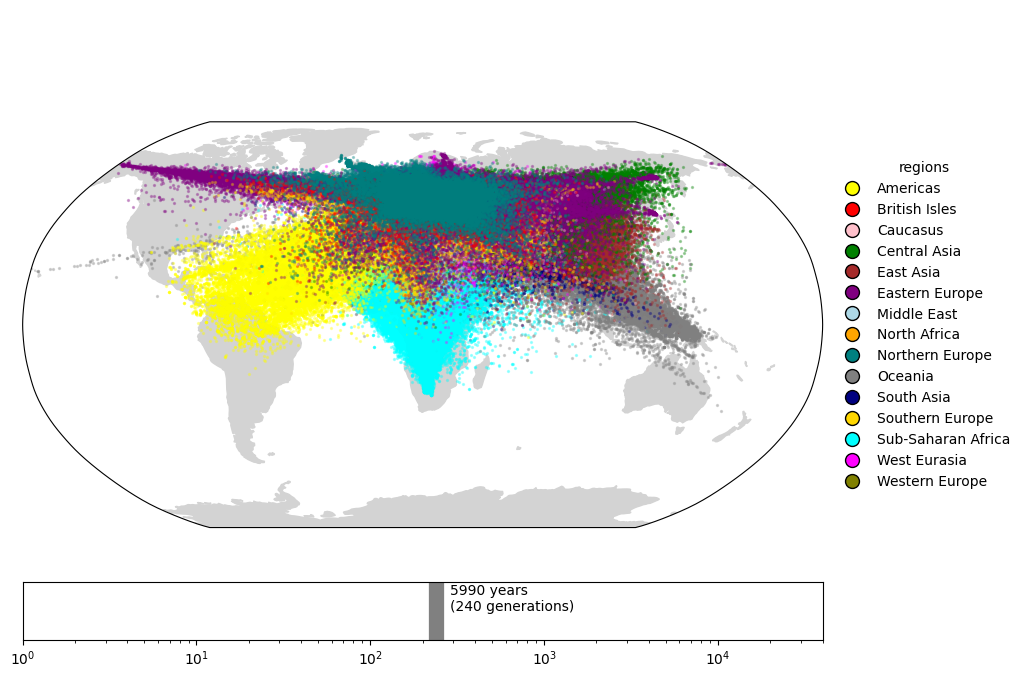

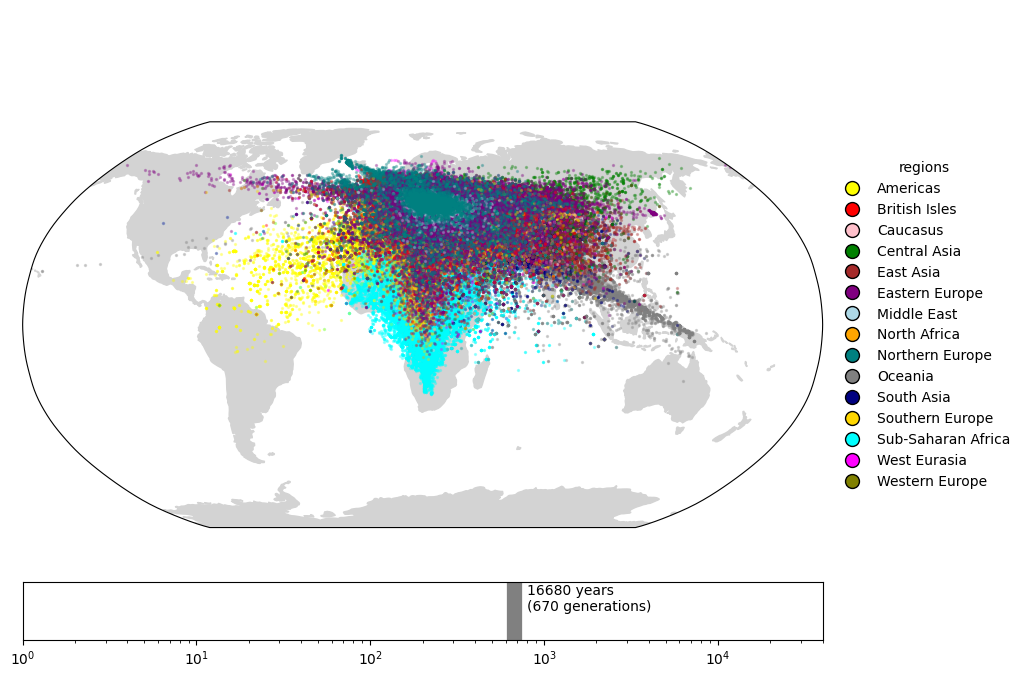

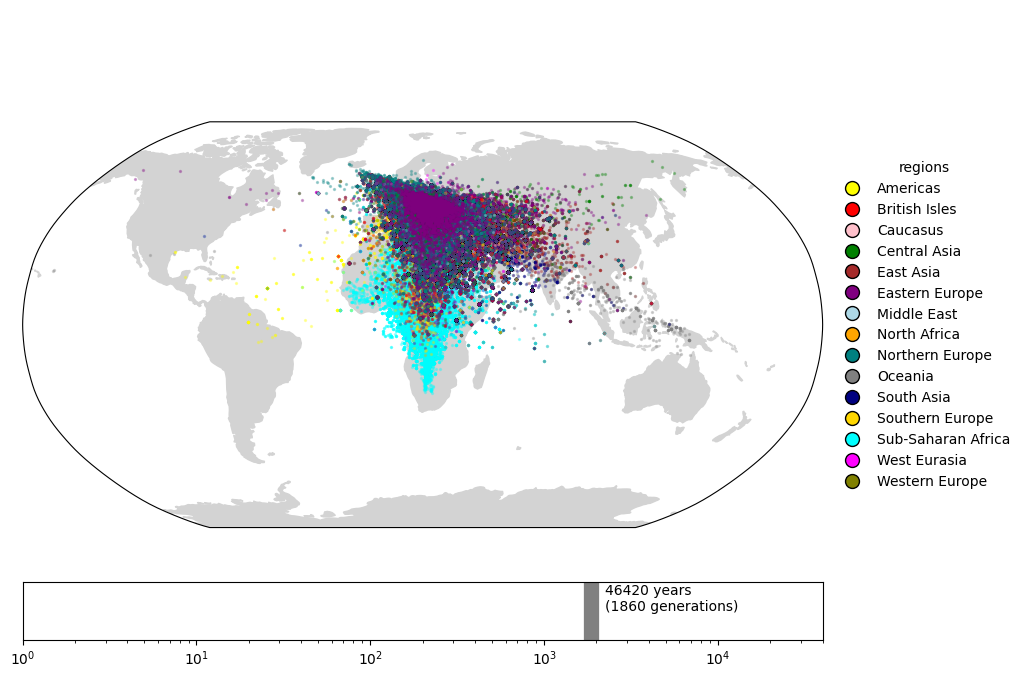

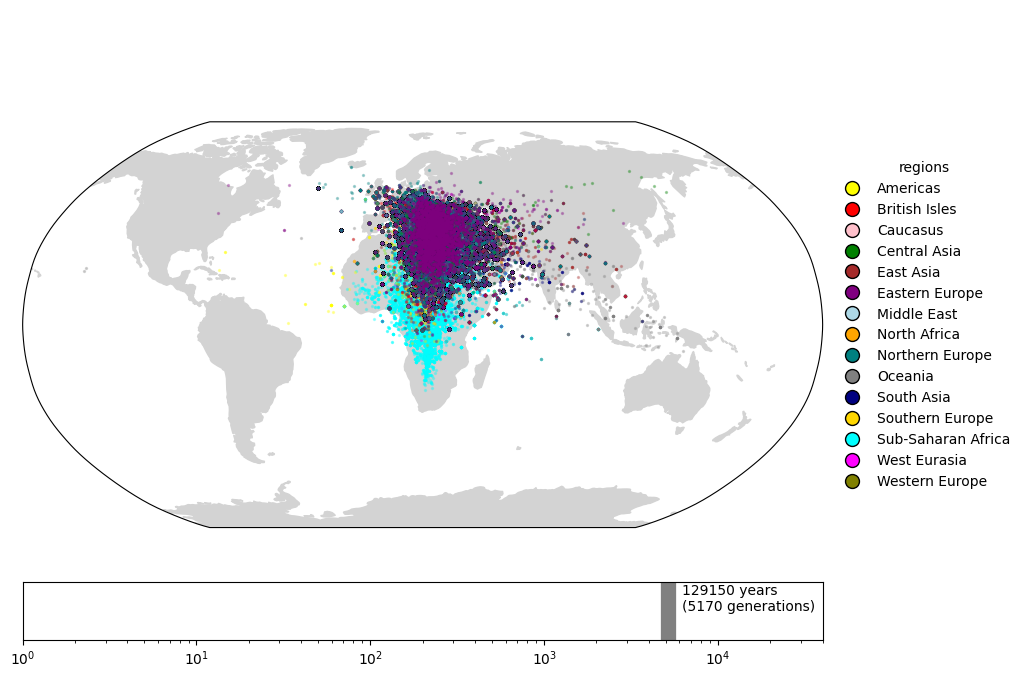

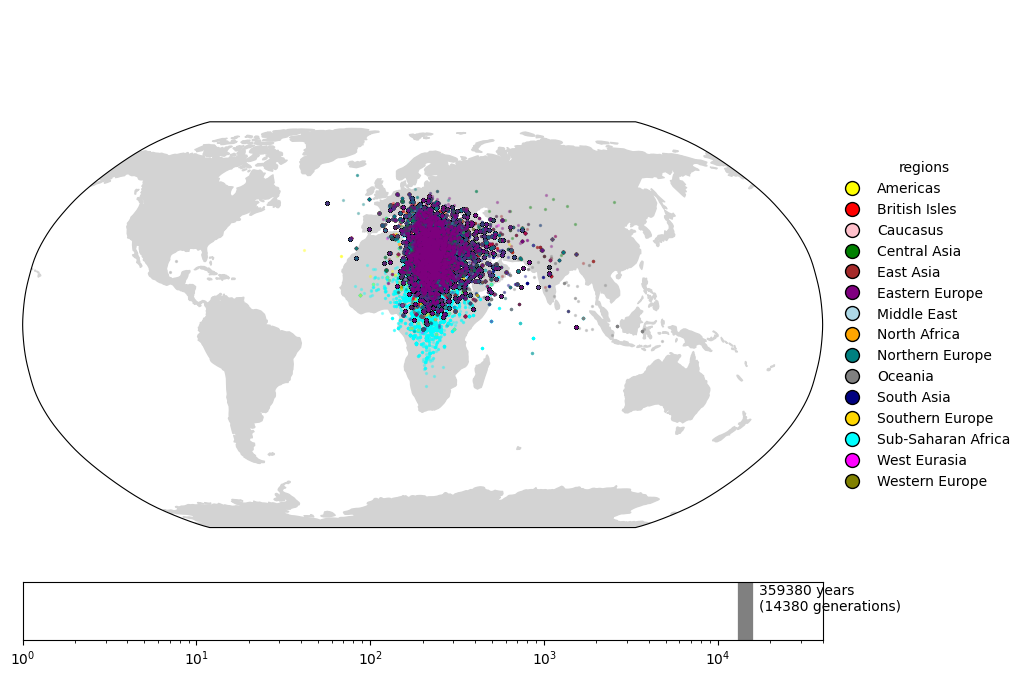

In [16]:
projection = ccrs.Robinson(central_longitude=20)
data_crs = ccrs.PlateCarree() #data supplied in lat/long
#TODO: Add sample locations plot
#ax.scatter(sample_locs[sample][0], sample_locs[sample][1], color=group_colors[group_ixs[sample]], s=2, alpha=1, zorder=0, transform=data_crs)
for time_ix in range(T-1):

    fig, axs = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[1, 0.1])
    ax = axs[0]
    ax.axis("off")
    dummy = axs[1]
    dummy.set_yticks([])
    
    ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND, color='lightgray')
    
    # plot all ancestors of each sample
    for sample in samples: 
        locs = anc_locs[:,sample,time_ix]
        ax.scatter(locs[:, 0], locs[:, 1], color=group_colors[group_ixs[sample]], s=2, alpha=0.3, zorder=0, transform=data_crs)

    # legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=i, 
                markeredgecolor='k', markersize=10, linestyle='') for i in group_colors]
    ax.legend(handles, group_names, title="regions", loc='center right', bbox_to_anchor=(1.25, 0.5), frameon=False)

    # timeline
    vline = dummy.axvline(ancestor_times[time_ix] if ancestor_times[time_ix]>0 else 1, linewidth=11, color="grey")
    dummy.set_xlim(1, ancestor_times[T-1])
    dummy.set_xscale("log")
    dummy.text(
            ancestor_times[time_ix]*1.2 if ancestor_times[time_ix]>0 else 1.2,
            0.5,
            str(int(np.round(ancestor_times[time_ix] * 25, -1)))
            + " years \n"
            + "("
            + str(int(np.round(ancestor_times[time_ix], -1)))
            + " generations)",
        )

    plt.subplots_adjust(left=0, bottom=0.1, right=0.8, top=1, wspace=0, hspace=0)
    # plt.tight_layout()
    plt.savefig(plotdir + 'group_%d.png' %time_ix)
    plt.show()

In [17]:
#Loading all the loci to get the mean later
pattern = 'data/SGDP_contemporary_only_chr2_*locus_10M_NoneT_Alls_Allt.blup_weightless_locs'

fns_contemporary = sorted(glob.iglob(pattern))
starts = [int(re.search(r'chr2_(\d+)locus', fn).group(1)) for fn in fns_contemporary]
locus_order = np.argsort(starts)
fnss_0_contemporary = [fns_contemporary[i] for i in locus_order]



anc_locs_0_contemporary = []
for i, fpath in enumerate(fnss_0_contemporary):
    df = pd.read_csv(fpath, header=None, names=["sample", "time", "lat", "lon", "var"])
    samples = sorted(df["sample"].unique())
    timepoints = sorted(df["time"].unique())

    n = len(samples)
    T = len(timepoints)
    
    if n * T != len(df):
        print(f"Skipping {fpath}: expected {n*T} rows but got {len(df)}")
        continue
    sample_map = {v: i for i, v in enumerate(samples)}
    time_map = {v: i for i, v in enumerate(timepoints)}

    # Map samples and times to indices
    s_idx = df["sample"].map(sample_map).values
    t_idx = df["time"].map(time_map).values

    # Pre-allocate array
    arr = np.full((n, T, 2), np.nan)

    # Fill lat/lon efficiently using broadcasting
    arr[s_idx, t_idx, 0] = df["lon"].values
    arr[s_idx, t_idx, 1] = df["lat"].values

    anc_locs_0_contemporary.append(arr)

anc_locs_0_contemporary = np.array(anc_locs_0_contemporary)  # shape: (L, n, T, 2)
print("Final shape:", anc_locs_0_contemporary.shape)

anc_locs_contemporary = anc_locs_0_contemporary

L, n, T, d = anc_locs_contemporary.shape
L, n, T, d

Final shape: (990, 556, 10, 2)


(990, 556, 10, 2)

*CONTEMPORARY INFERENCE*

In [18]:
# Using continuous logarithmic color map 
from matplotlib.colors import LogNorm
fig = plt.figure(figsize=(10, 6), dpi=100, edgecolor='k')
projection = ccrs.Robinson(central_longitude=20)
data_crs = ccrs.PlateCarree() #data supplied in lat/long
geodetic = ccrs.Geodetic() #for great circles
ax = plt.axes(projection=projection)
ax.set_global()
ax.add_feature(cfeature.LAND, color='lightgray')
cmap = plt.get_cmap("plasma_r")
norm = LogNorm(vmin=1, vmax=40005)


for sample in samples_contemporary: #samples: #for each sample
    #if (sample != 3000):
        #continue
    # get mean ancestor location at all times
    time_vals = []  # store when we start collecting samples

    sample_added = False
    mean_locs = []
    sample_time = sample_times[sample]
    is_ancient = []
    

    for time_ix in range(T):
        if ancestor_times[time_ix] < sample_time:
            print("WRONG")
            #assert np.isnan(anc_locs[:, sample, time_ix]).all() #ensure that we only have nans
            try:
                assert np.isnan(anc_locs[:, sample, time_ix]).all()
            except AssertionError:
                print(f"Assertion failed at sample={sample}, time_ix={time_ix}")
                print(f"anc_locs[:, sample, time_ix] = {anc_locs[:, sample, time_ix]}")
                raise
            #time_vals.append(-1)
            #mean_locs.append(-1)
            is_ancient.append(True)
            continue

        if not sample_added:1
            mean_locs.append(sample_locs[sample])
            time_vals.append(sample_time)
            sample_added = True

        locs = anc_locs_contemporary[:, sample, time_ix]
        assert not np.isnan(locs).any() #check there are NO nans
        mean_loc = np.mean(locs, axis=0)
        mean_locs.append(mean_loc)
        time_vals.append(ancestor_times[time_ix])
        is_ancient.append(False)

    mean_locs = np.array(mean_locs)
    time_vals = np.array(time_vals)

    assert (len(mean_locs) == len(time_vals))
    for i in range(len(mean_locs) - 1):
        # t_norm = (time_vals[i+1] - min_time) / (max_time - min_time)
        # color = cmap(t_norm)
        if time_vals[i] == 0:
            color = 'black'
        else:
            color = cmap(norm(time_vals[i]))

        x0, y0 = mean_locs[i, 0], mean_locs[i, 1]
        x1, y1 = mean_locs[i+1, 0], mean_locs[i+1, 1]

        if np.any(np.isnan([x0, y0, x1, y1])):
            continue

        if (is_ancient[i]):
            ax.plot([x0, x1], [y0, y1], color=color, lw=1, alpha=0.5,
                    transform=geodetic, marker='o', markerfacecolor='none')
        else:
            ax.plot([x0, x1], [y0, y1], color=color, lw=1, alpha=0.5,
                    transform=geodetic, marker='o')

cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap=cmap), ax=ax, orientation='horizontal', pad=0.05, shrink=0.9)
# cbar.set_ticks([i/4 for i in range(5)])
# cbar.set_ticklabels(np.round(np.logspace(1,np.log10(ancestor_times[time_ix]),5)*25).astype(int).tolist())
ts = [10**i for i in range(7)]
cbar.set_ticks(np.log10(ts)/np.log10(ancestor_times[time_ix]*25)) #gen time = 25 years
cbar.set_ticklabels(ts)
cbar.set_label(('years ago'), fontsize=14)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig(plotdir + 'continous_log_time_scale.png')
plt.show()
#print(f'Number of ancient samples: {count_ancients}')

IndentationError: unexpected indent (293949863.py, line 42)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Slice the first 556 samples from anc_locs to match anc_locs_contemporary
c

# Step 4: Plot histogram of shift at final timepoint
final_time_ix = 9
plt.figure(figsize=(10, 6))
plt.hist(shift_magnitude[:, final_time_ix], bins=50, color='teal', edgecolor='black')
plt.title(f"Shift in inferred location (with vs without ancient samples) at time point {ancestor_times[final_time_ix]}")
plt.xlabel("Euclidean shift (degrees)")
plt.ylabel("Number of samples")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 5: Print average shift over all timepoints
avg_shift_per_sample = np.nanmean(shift_magnitude, axis=1)  # shape: (556,)
print(f"Mean shift across all samples: {np.nanmean(avg_shift_per_sample):.4f} degrees")


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Plot 10 maps for time points 0 to 9
for time_point in range(10):
    fig = plt.figure(figsize=(10, 6), dpi=100, edgecolor='k')
    projection = ccrs.Robinson(central_longitude=20)
    data_crs = ccrs.PlateCarree()  # data in lat/lon
    geodetic = ccrs.Geodetic()     # for great circles
    ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND, color='lightgray')

    for sample in samples_contemporary:
        ancient_locs = anc_locs[:, sample, time_point]
        if np.isnan(ancient_locs).all():
            continue

        contemporary_locs = anc_locs_contemporary[:, sample, time_point]
        if np.isnan(contemporary_locs).all():
            continue

        mean_ancient = np.mean(ancient_locs, axis=0)
        mean_contemporary = np.mean(contemporary_locs, axis=0)

        anc_x, anc_y = mean_ancient
        con_x, con_y = mean_contemporary

        # Plot ancient and contemporary points
        ax.plot(anc_x, anc_y, 'o', color='red', markersize=6, transform=data_crs,
                label='Ancient' if sample == samples_contemporary[0] else "")
        ax.plot(con_x, con_y, 'o', color='blue', markersize=6, transform=data_crs,
                label='Contemporary' if sample == samples_contemporary[0] else "")

        # Line showing shift
        ax.plot([anc_x, con_x], [anc_y, con_y], color="orange", lw=1.2, alpha=0.7, transform=geodetic)

    ax.set_title(f"Ancestral Shift – Time Point {ancestor_times[time_point].round()}", fontsize=14)
    ax.legend(loc='lower left')
    plt.tight_layout()
    plt.show()


In [ ]:
sample_loc_ancients = sample_locs [557:len(sample_locs)]
sample_loc_contemporaries = sample_locs [0:557]



mean_a = np.mean(sample_loc_ancients, axis = 0)
mean_c = np.mean(sample_loc_contemporaries, axis = 0)

print(mean_a[0])

fig = plt.figure(figsize=(10, 6), dpi=100, edgecolor='k')
projection = ccrs.Robinson(central_longitude=20)
data_crs = ccrs.PlateCarree()  # data in lat/lon
geodetic = ccrs.Geodetic()     # for great circles
ax = plt.axes(projection=projection)
ax.set_global()
ax.add_feature(cfeature.LAND, color='lightgray')

ax.scatter(mean_a[0], mean_a[1],  color="orange", alpha=0.7, transform=geodetic)
ax.scatter(mean_c[0], mean_c[1], color="blue", alpha=0.7, transform=geodetic)

plt.tight_layout()
plt.show()